# IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/Bumb1eBee20/ExcelR---Data-Science-Assignments-Submissions/c94a11326b41ce3ba21f57e0f8b800c36495eded/10.%20SVM/data/Pharma_Industry.csv"
df = pd.read_csv(url)

# Preview of the Dataset

In [3]:
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


# Initial Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


## Dataset Dimensions

In [5]:
print("Shape : ",df.shape)
print("Size ; ",df.size)

Shape :  (500, 6)
Size ;  3000


## Check DataTypes

In [6]:
df.dtypes

,0
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64


# Data Cleaning

## Check for Missing Values

In [7]:
print("No.of Missing Values :\n")
print(df.isnull().sum())

No.of Missing Values :

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64


## Check for Duplicate Records

In [8]:
print("No.of Duplicated Records : ",df.duplicated().sum())

No.of Duplicated Records :  0


## **Observation :**

The Dataset has no Missing Values and Duplicate Records as of now.

# Descriptive Statistical Analysis

In [9]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [10]:
Stat_Summary = pd.DataFrame({"Mean":df.mean(numeric_only=True),
                            "Median":df.median(numeric_only=True),
                            "Mode":df.mode(numeric_only=True).iloc[0],
                            "Min":df.min(numeric_only=True),
                            "Max":df.max(numeric_only=True),
                            "Standard Deviation":df.std(numeric_only=True)})
Stat_Summary

,Mean,Median,Mode,Min,Max,Standard Deviation
Drug Dosage (mg),-0.037761,-0.019340,-3.019512,-3.019512,2.949094,0.979891
Systolic Blood Pressure (mmHg),0.214957,0.201532,-3.773897,-3.773897,4.111751,1.247567
Heart Rate (BPM),0.062871,0.027732,-2.940389,-2.940389,3.193108,0.971978
Liver Toxicity Index (U/L),0.054398,-0.065661,-3.401277,-3.401277,3.373269,0.986001
Blood Glucose Level (mg/dL),-0.171863,-0.108106,-3.110431,-3.110431,2.518023,0.983765
Drug Response,0.520000,1.000000,1.000000,0.000000,1.000000,0.500100


## **Observation :**

- The numerical features have values centered around zero and include negative values, suggesting that the dataset may have been standardized or normalized. Therefore, the negative values should not necessarily be interpreted as biologically impossible measurements.- The Drug Response is a discrete variable which only consists of 0 and 1.
- `Drug Dosage (mg)`, `Systolic Blood Pressure (mmHg)`, `Heart Rate (BPM)`, `Liver Toxicity Index (U/L)`,`Blood Glucose Level (mg/dL)` may have potential outliers as per the stats.

# Exploratory Data Analysis

In [11]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [12]:
num_cols  = ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)']

## Boxplot Analysis

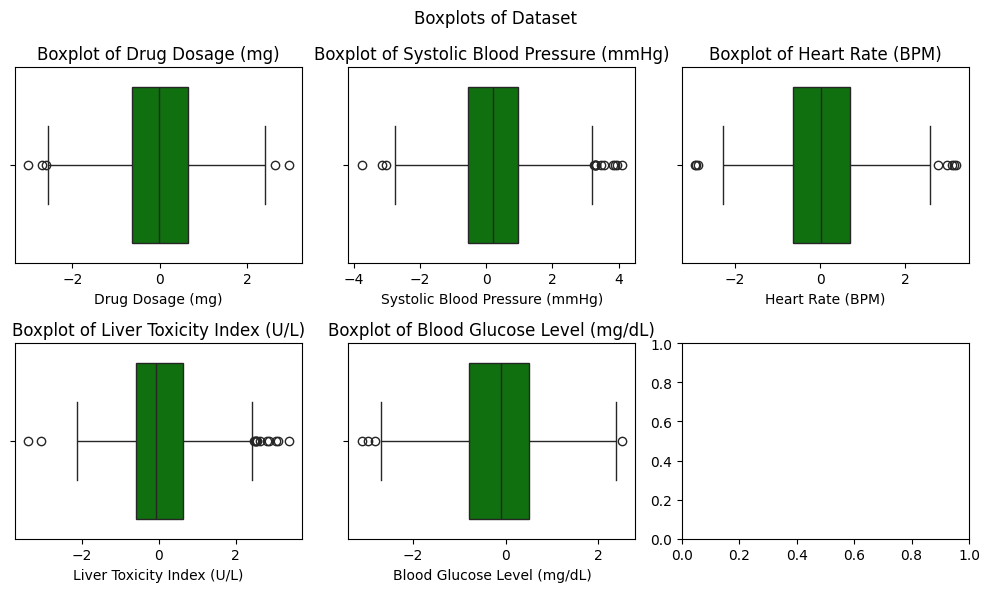

In [13]:
fig, ax = plt.subplots(2,3,figsize=(10,6))

for axis,col in zip(ax.flat,num_cols):
  sns.boxplot(data=df,x=col,ax=axis,color = "g")
  axis.set_title(f"Boxplot of {col}")
  axis.set_xlabel(col)
plt.suptitle("Boxplots of Dataset")
plt.tight_layout()
plt.show()

## Histogram Analysis

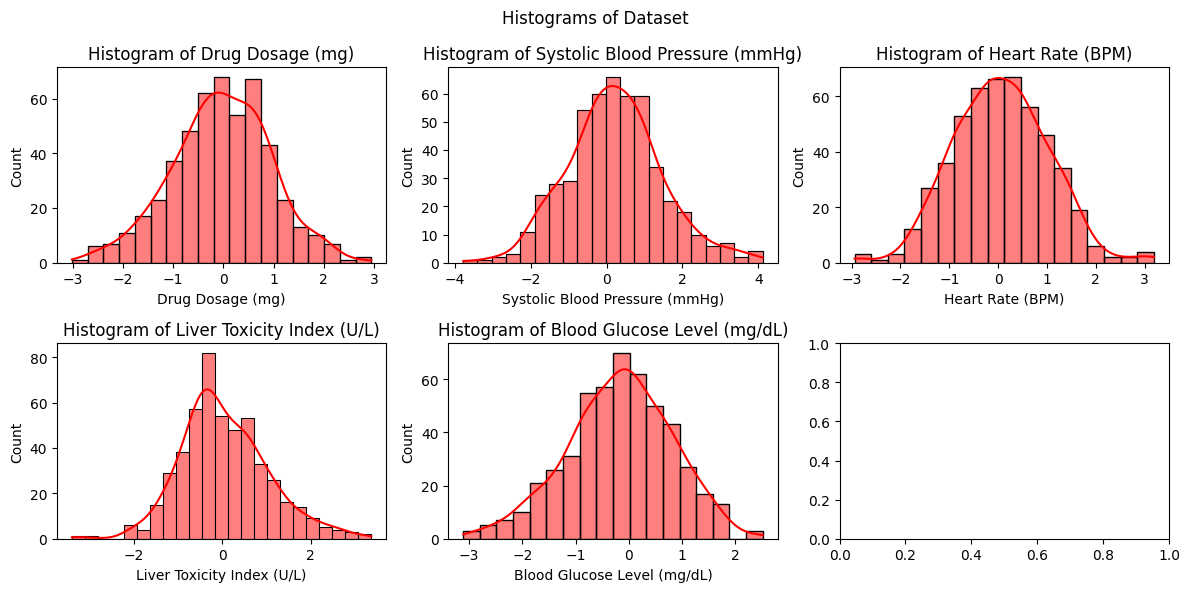

In [14]:
fig, ax = plt.subplots(2,3,figsize=(12,6))

for axis,col in zip(ax.flat,num_cols):
  sns.histplot(data=df,x=col,ax=axis,color = "red",kde=True)
  axis.set_title(f"Histogram of {col}")
  axis.set_xlabel(col)
plt.suptitle("Histograms of Dataset")
plt.tight_layout()
plt.show()

## Countplot Analysis

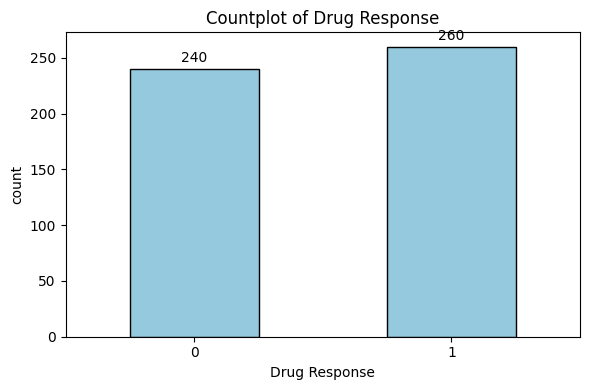

In [15]:
plt.figure(figsize=(6,4))
axis = sns.countplot(data=df,x = df["Drug Response"],color = "skyblue",edgecolor="black",width = 0.5)
plt.title("Countplot of Drug Response")
plt.xlabel("Drug Response")

for container in axis.containers:
  axis.bar_label(container,padding=3)

plt.tight_layout()
plt.show()

## Correlation Analysis

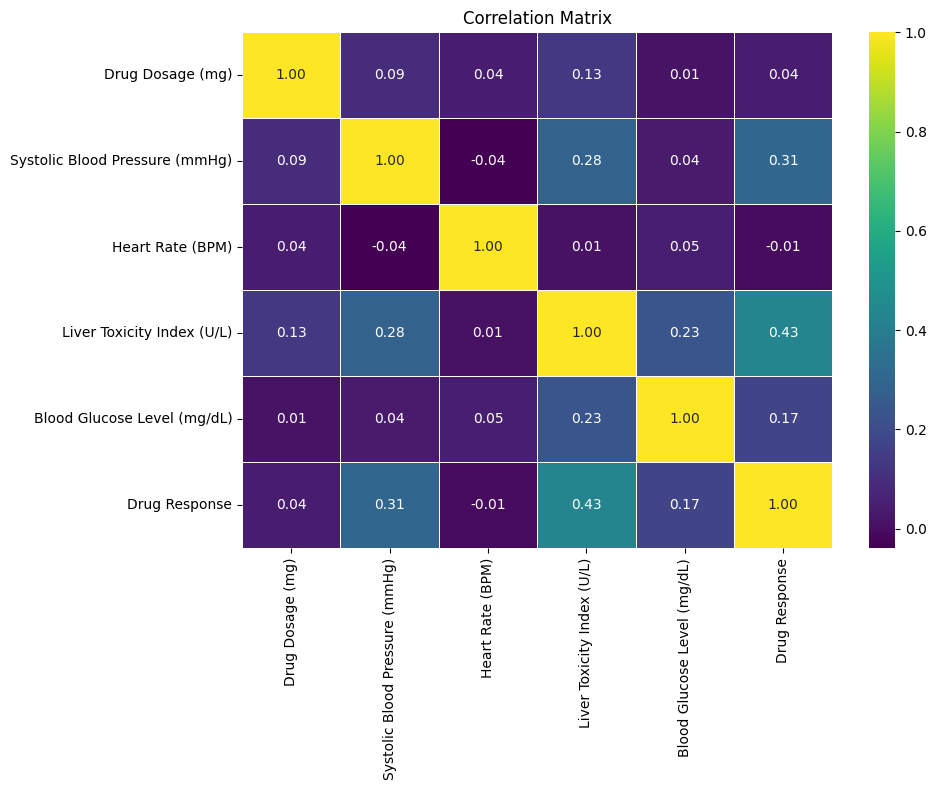

In [16]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(),annot=True,fmt=".2f",linewidths=0.5,cmap="viridis")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Data Preprocessing

## Feature and Target Separation

The dataset is divided into:

- **Features (X):** Independent variables used to predict the drug response.
- **Target (y):** Drug Response, where:
  - 0 represents No Response
  - 1 represents Positive Response

In [17]:
X = df[num_cols]
y = df["Drug Response"]

print("X Shape : ",X.shape)
print("y Shape : ",y.shape)

X Shape :  (500, 5)
y Shape :  (500,)


## Train-Test Split

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("X_train Shape : ",X_train.shape)
print("X_test Shape : ",X_test.shape)
print("y_train Shape : ",y_train.shape)
print("y_test Shape : ",y_test.shape)

X_train Shape :  (400, 5)
X_test Shape :  (100, 5)
y_train Shape :  (400,)
y_test Shape :  (100,)


## Feature Scaling

In [19]:
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

# SVM

In [20]:
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train_Scaled,y_train)

SVC(kernel='linear')

## Prediction

In [21]:
# Make predictions on the testing data

y_pred = svm_linear.predict(X_test_Scaled)

# Display the first 10 predictions
print("Predicted Values:")
print(y_pred[:10])

print("\nActual Values:")
print(y_test.values[:10])

Predicted Values:
[1 1 1 0 0 1 1 0 1 1]

Actual Values:
[1 0 1 0 0 1 0 0 1 1]


## Evaluation Metrics

In [22]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

Eval_Summary = pd.DataFrame({"Accuracy":[accuracy],"Precision":[precision],
                            "Recall":[recall],"F1":[f1]})
Eval_Summary

,Accuracy,Precision,Recall,F1
0,0.72,0.76087,0.673077,0.714286


In [23]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



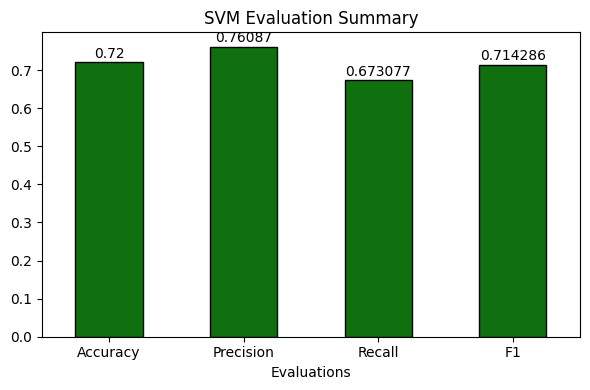

In [24]:
plt.figure(figsize=(6,4))
axis = sns.barplot(data=Eval_Summary,color = "green",edgecolor="black",width = 0.5)
plt.title("SVM Evaluation Summary")
plt.xlabel("Evaluations")

for container in axis.containers:
  axis.bar_label(container,padding=1)

plt.tight_layout()
plt.show()

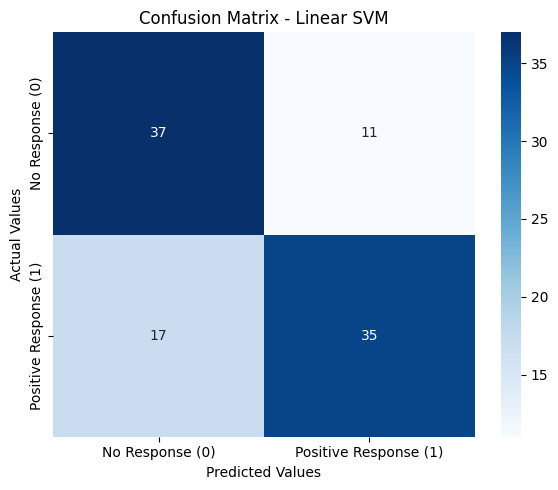

In [25]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot = True,fmt="d",cmap="Blues",
            xticklabels = ["No Response (0)","Positive Response (1)"],
            yticklabels = ["No Response (0)","Positive Response (1)"])

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.tight_layout()
plt.show()

## Observation

The Linear SVM model achieved an accuracy of approximately **72%** on the testing dataset.

The model achieved:

- A precision of approximately **76%**, indicating that many predicted positive drug responses were correct.
- A recall of approximately **67%**, indicating that the model identified around two-thirds of the actual positive responses.
- An F1-score of approximately **71%**, showing a moderate balance between precision and recall.

Overall, the Linear SVM model provides a reasonable baseline performance, but further hyperparameter tuning and comparison with other kernels may improve the results.

# SVM Kernel Comparison

Different SVM kernels are compared to determine which kernel provides the best classification performance for the Drug Response dataset.

The following kernels are evaluated:

- Linear Kernel
- Polynomial Kernel
- RBF (Radial Basis Function) Kernel

In [26]:
# Create SVM models with different kernels

svm_models = {
    "Linear": SVC(kernel="linear"),
    "Polynomial": SVC(kernel="poly"),
    "RBF": SVC(kernel="rbf")
}

# Store results
results = []

# Train and evaluate each model
for kernel_name, model in svm_models.items():

    # Train the model
    model.fit(X_train_Scaled, y_train)

    # Make predictions
    y_pred_kernel = model.predict(X_test_Scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred_kernel)
    precision = precision_score(y_test, y_pred_kernel)
    recall = recall_score(y_test, y_pred_kernel)
    f1 = f1_score(y_test, y_pred_kernel)

    # Store results
    results.append({
        "Kernel": kernel_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Create a DataFrame
kernel_results = pd.DataFrame(results)

kernel_results

,Kernel,Accuracy,Precision,Recall,F1 Score
0,Linear,0.72,0.760870,0.673077,0.714286
1,Polynomial,0.65,0.666667,0.653846,0.660194
2,RBF,0.77,0.754386,0.826923,0.788991


## Kernel Comparison Observation

The performance of SVM models using Linear, Polynomial, and RBF kernels was compared.

The **RBF kernel performed the best overall**, achieving the highest accuracy of **77%**, recall of **82.7%**, and F1-score of **78.9%**.

The Linear kernel achieved an accuracy of **72%**, while the Polynomial kernel showed the lowest performance with an accuracy of **65%**.

Although the Linear kernel achieved slightly higher precision than the RBF kernel, the RBF model demonstrated better overall performance due to its higher recall and F1-score.

Therefore, the **RBF kernel is selected as the best-performing SVM model for this dataset**.

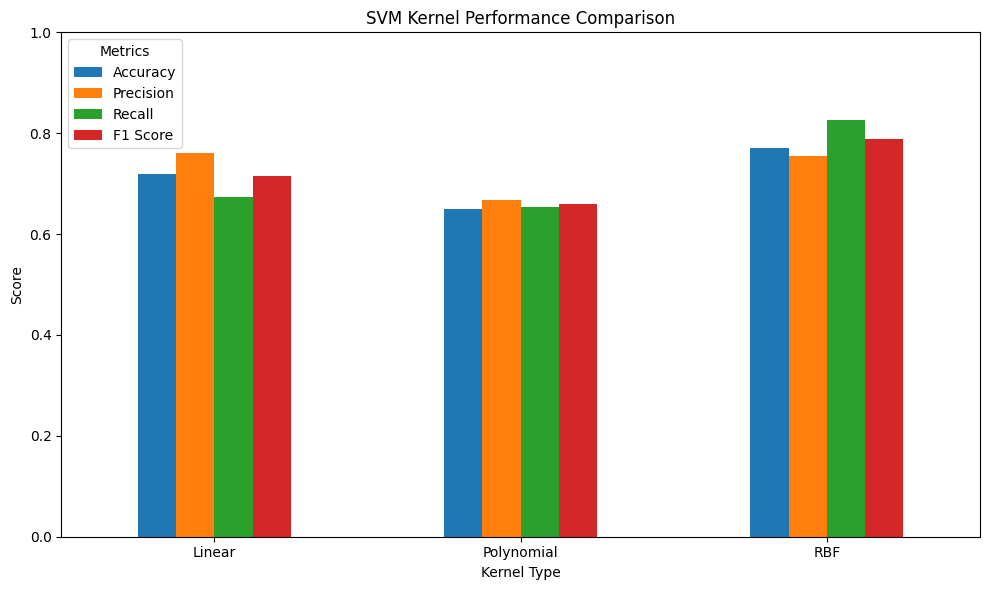

In [27]:
# Set Kernel as the index for visualization
kernel_results_plot = kernel_results.set_index("Kernel")

# Plot the evaluation metrics
kernel_results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("SVM Kernel Performance Comparison")
plt.xlabel("Kernel Type")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(title="Metrics")

plt.tight_layout()
plt.show()

## Visualization Interpretation

The bar chart compares the performance of SVM models using Linear, Polynomial, and RBF kernels across Accuracy, Precision, Recall, and F1-score.

The **RBF kernel demonstrates the best overall performance**, particularly in terms of Recall and F1-score. It also achieved the highest Accuracy among all three models.

The **Linear kernel performed moderately well**, with the highest Precision, but its Recall was lower than that of the RBF kernel.

The **Polynomial kernel showed the weakest overall performance** across the evaluated metrics.

Therefore, based on the comparison, the **RBF kernel is selected as the best-performing kernel for the Drug Response Classification dataset**.

# Hyperparameter Tuning

Hyperparameter tuning is performed to optimize the performance of the RBF SVM model.

`GridSearchCV` is used to test different combinations of the `C` and `gamma` parameters and identify the combination that provides the best cross-validation performance.

In [28]:
from sklearn.model_selection import GridSearchCV

# Define the RBF SVM model
svm_rbf = SVC(kernel="rbf")

# Define the hyperparameter values to test
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1]
}

# Perform Grid Search with Cross Validation
grid_search = GridSearchCV(
    estimator=svm_rbf,
    param_grid=param_grid,
    cv=5,
    scoring="f1"
)

# Train the Grid Search model
grid_search.fit(X_train_Scaled, y_train)

# Display the best parameters
print("Best Parameters:", grid_search.best_params_)

# Display the best cross-validation score
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

Best Parameters: {'C': 1, 'gamma': 1}
Best Cross-Validation F1 Score: 0.7715796643339201


## Evaluation of the Tuned RBF Model

The best hyperparameters identified through GridSearchCV are used to evaluate the optimized RBF SVM model on the testing dataset.

The model performance is evaluated using Accuracy, Precision, Recall, and F1-score.

In [29]:
# Get the best model from GridSearchCV
best_svm = grid_search.best_estimator_

# Make predictions on the test dataset
y_pred_tuned = best_svm.predict(X_test_Scaled)

# Calculate evaluation metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

# Display the results
print("Tuned RBF SVM Performance:\n")

print(f"Accuracy: {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall: {tuned_recall:.4f}")
print(f"F1 Score: {tuned_f1:.4f}")

Tuned RBF SVM Performance:

Accuracy: 0.7200
Precision: 0.7143
Recall: 0.7692
F1 Score: 0.7407


## Hyperparameter Tuning Results

GridSearchCV identified the best hyperparameters as:

- **C = 1**
- **gamma = 1**

The best cross-validation F1-score obtained during tuning was approximately **0.7716**.

However, when the optimized model was evaluated on the unseen testing dataset, its performance was lower than the default RBF SVM model.

The default RBF model achieved an accuracy of **77%** and an F1-score of approximately **78.9%**, whereas the tuned RBF model achieved an accuracy of **72%** and an F1-score of approximately **74.1%**.

Therefore, despite the hyperparameter tuning process, the **default RBF SVM model demonstrated better generalization performance on the testing dataset** and is selected as the final model.

In [30]:
# Create a final comparison DataFrame

final_results = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Polynomial SVM",
        "Default RBF SVM",
        "Tuned RBF SVM"
    ],

    "Accuracy": [
        0.72,
        0.65,
        0.77,
        0.72
    ],

    "Precision": [
        0.760870,
        0.666667,
        0.754386,
        0.714286
    ],

    "Recall": [
        0.673077,
        0.653846,
        0.826923,
        0.769231
    ],

    "F1 Score": [
        0.714286,
        0.660194,
        0.788991,
        0.740741
    ]
})

final_results# Create a final comparison DataFrame

final_results = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Polynomial SVM",
        "Default RBF SVM",
        "Tuned RBF SVM"
    ],

    "Accuracy": [
        0.72,
        0.65,
        0.77,
        0.72
    ],

    "Precision": [
        0.760870,
        0.666667,
        0.754386,
        0.714286
    ],

    "Recall": [
        0.673077,
        0.653846,
        0.826923,
        0.769231
    ],

    "F1 Score": [
        0.714286,
        0.660194,
        0.788991,
        0.740741
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.72,0.760870,0.673077,0.714286
1,Polynomial SVM,0.65,0.666667,0.653846,0.660194
2,Default RBF SVM,0.77,0.754386,0.826923,0.788991
3,Tuned RBF SVM,0.72,0.714286,0.769231,0.740741


## Strengths of Support Vector Machine

Based on the results obtained from the Drug Response Classification dataset, the following strengths of SVM were observed:

- SVM was able to achieve good classification performance, particularly with the RBF kernel.
- The RBF kernel achieved the highest accuracy of **77%** and the highest F1-score of approximately **78.9%**.
- SVM can model complex and non-linear relationships using kernels such as the RBF kernel.
- Feature scaling helped ensure that all numerical features contributed appropriately to the model.
- The model demonstrated good recall for identifying patients with a positive drug response.

## Weaknesses of Support Vector Machine

The following limitations were observed:

- The performance of SVM depends on the selection of the kernel and hyperparameters.
- The Polynomial kernel performed poorly compared to the Linear and RBF kernels.
- Hyperparameter tuning did not improve the performance of the RBF model on the testing dataset.
- SVM models can be sensitive to feature scaling.
- The model still produced incorrect classifications, including False Positives and False Negatives.

## Practical Implications

The SVM model can potentially be used as a decision-support tool for predicting whether a patient may show a positive response to a particular drug.

The model could help identify patterns in patient-related measurements such as drug dosage, blood pressure, heart rate, liver toxicity, and blood glucose levels.

Early prediction of drug response could potentially help pharmaceutical researchers analyze drug effectiveness more efficiently and support personalized treatment decisions.

However, the model should not be considered a replacement for clinical judgment. Further validation using larger and real-world datasets would be necessary before practical medical deployment.

# Conclusion

In this assignment, Support Vector Machine (SVM) models were implemented to classify patient drug responses.

Exploratory Data Analysis was performed to understand the dataset, feature distributions, correlations, and class distribution. The dataset was then divided into training and testing sets, and feature scaling was applied before training the SVM models.

Three different kernels were compared: Linear, Polynomial, and RBF.

The results showed that the **RBF kernel performed best overall**, achieving an accuracy of **77%** and an F1-score of approximately **78.9%**.

Hyperparameter tuning using GridSearchCV was also performed. Although the tuning process identified **C = 1** and **gamma = 1** as the best parameters based on cross-validation performance, the tuned model performed worse on the testing dataset.

Therefore, the **default RBF SVM model was selected as the final model** because it demonstrated the best generalization performance on the unseen test data.

Overall, this analysis demonstrates that SVM can be an effective approach for Drug Response Classification, particularly when non-linear relationships between features and the target variable are present.